# Modelo 2 - EfficientNet B23


Este notebook utiliza `EfficientNet-B3` como modelo principal para la clasificación de deepfakes. EfficientNet es una familia de arquitecturas de visión por computadora desarrollada por Google en 2019, que logra un buen equilibrio entre precisión y eficiencia computacional mediante un escalado compuesto de profundidad, anchura y resolución.

Se elige la versión `B3` por los siguientes motivos:
- `B3` es una versión intermedia con mayor capacidad que `B0/B1/B2`, pero sin requerir la memoria extrema de versiones más grandes como `B5` o `B7`.
- Su tamaño y cantidad de parámetros permiten capturar patrones faciales complejos sin causar un coste de entrenamiento demasiado alto.
- Es especialmente adecuada para tareas de detección de deepfake, donde el detalle de la imagen y la generalización son importantes.

En este caso se trabaja con imágenes redimensionadas a `300x300`, que es la resolución de entrada recomendada para `EfficientNet-B3` cuando se aprovechan sus pesos preentrenados en ImageNet.

## Configuración, Dataset y Transformaciones

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
import os
import timm
import ssl
from tqdm import tqdm
from livelossplot import PlotLosses

# Parche SSL
ssl._create_default_https_context = ssl._create_unverified_context

# Configuración de dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔥 Entrenando en: {device}")

# --- CLASE DATASET (Mantenemos lógica de CSV) ---
class DeepfakeDataset(Dataset):
    def __init__(self, csv_path, split='train', transform=None):
        self.df = pd.read_csv(csv_path)
        self.df = self.df[self.df['split'] == split].reset_index(drop=True)
        self.transform = transform
        self.label_dict = {'real': 0, 'fake': 1}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['path']
        label_name = self.df.iloc[idx]['label']
        label = self.label_dict[label_name]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

# --- TRANSFORMACIONES ESPECÍFICAS EFFICIENTNET-B3 (300x300) ---
# Usamos la normalización estándar de ImageNet
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((300, 300)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((300, 300)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Carga de DataLoaders
CSV_PATH = r'C:\TFG\Dataset_Final_Procesado\registro_datos.csv'
train_dataset = DeepfakeDataset(CSV_PATH, split='train', transform=data_transforms['train'])
test_dataset = DeepfakeDataset(CSV_PATH, split='test', transform=data_transforms['test'])

# num_workers=0 es más seguro en Windows para evitar errores de memoria
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

print(f"✅ Dataset cargado: {len(train_dataset)} train, {len(test_dataset)} test.")

🔥 Entrenando en: cuda
✅ Dataset cargado: 23932 train, 5967 test.


## Definición del Modelo EfficientNet-B3

In [3]:
# 1. Cargamos EfficientNet-B3
model = timm.create_model('efficientnet_b3', pretrained=True, num_classes=2)
model = model.to(device)

# 2. Optimizador AdamW (mejor que Adam para prevenir overfitting)
# Iniciamos con el LR de tu Fase 1
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-2)

# 3. Función de pérdida con Label Smoothing
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# 4. Gráficas
liveloss = PlotLosses()

print("✅ EfficientNet-B3 listo y optimizador configurado.")

✅ EfficientNet-B3 listo y optimizador configurado.


## Bucle de Entrenamiento con Fine-Tuning y Gráficas

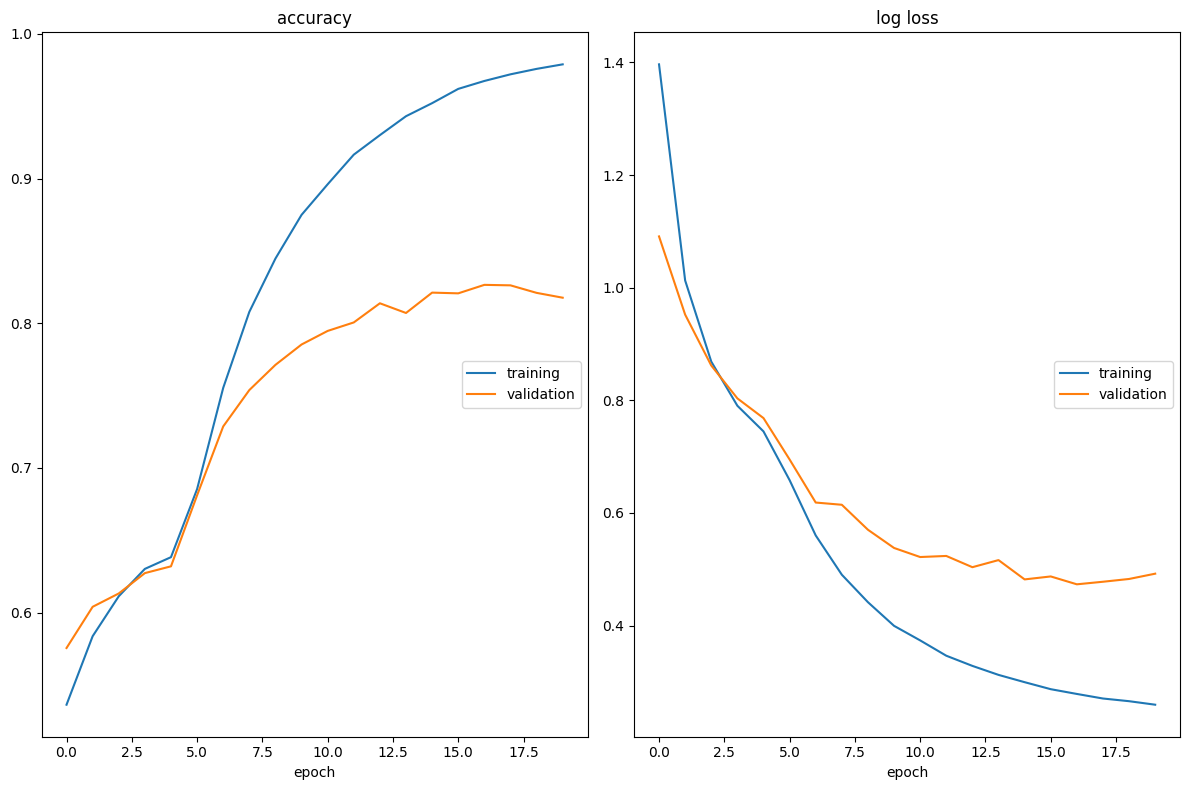

accuracy
	training         	 (min:    0.536, max:    0.979, cur:    0.979)
	validation       	 (min:    0.575, max:    0.827, cur:    0.818)
log loss
	training         	 (min:    0.259, max:    1.397, cur:    0.259)
	validation       	 (min:    0.473, max:    1.091, cur:    0.492)


In [4]:
EPOCHS = 20
patience = 5
counter = 0
best_val_loss = float('inf')
best_acc = 0.0

# --- FASE 1: CONGELAR BASE ---
print("🧊 Fase 1: Entrenando solo la 'cabeza' (Classifier)...")
for param in model.parameters():
    param.requires_grad = False
# En EfficientNet de timm, la capa final se suele llamar 'classifier'
for param in model.get_classifier().parameters():
    param.requires_grad = True

for epoch in range(EPOCHS):
    # --- FASE 2: DESCONGELAR (Época 5) ---
    if epoch == 5:
        print("🔥 Fase 2: Fine-Tuning profundo del modelo completo...")
        for param in model.parameters():
            param.requires_grad = True
        # Bajamos el LR drásticamente
        for param_group in optimizer.param_groups:
            param_group['lr'] = 1e-5

    logs = {}
    for phase in ['train', 'test']:
        if phase == 'train':
            model.train()
            dataloader = train_loader
        else:
            model.eval()
            dataloader = test_loader

        running_loss = 0.0
        running_corrects = 0

        # Barra de progreso tqdm
        pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{EPOCHS} [{phase}]")
        
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            
            # Mostrar loss actual en la barra
            pbar.set_postfix({'loss': f"{loss.item():.4f}"})

        epoch_loss = running_loss / len(dataloader.dataset)
        epoch_acc = running_corrects.double() / len(dataloader.dataset)

        prefix = '' if phase == 'train' else 'val_'
        logs[prefix + 'log loss'] = epoch_loss
        logs[prefix + 'accuracy'] = epoch_acc.item()
        
        # Guardado y Early Stopping
        if phase == 'test':
            if epoch_acc > best_acc:
                best_acc = epoch_acc
                torch.save(model.state_dict(), r'C:\TFG\modelos\best_effnet_acc.pth')
            
            if epoch_loss < best_val_loss:
                best_val_loss = epoch_loss
                counter = 0
                torch.save(model.state_dict(), r'C:\TFG\modelos\best_effnet_loss.pth')
            else:
                counter += 1

    # ACTUALIZACIÓN DE GRÁFICAS (Igual que en Xception)
    liveloss.update(logs)
    liveloss.send()

    if counter >= patience:
        print(f"🛑 Early Stopping en la época {epoch+1}.")
        break

## 📊Análisis.
Los valores proporcionados muestran un comportamiento típico de un modelo que aprende, pero con margen de mejora.

- `accuracy training`: min 0.536, max 0.979, cur 0.979.
  - El entrenamiento alcanza casi el 98 %, lo que indica que el modelo está memorizando bien los ejemplos de entrenamiento.
  - El rango amplio sugiere que el aprendizaje fue progresivo y que el modelo partió desde una fase inicial débil.

- `accuracy validation`: min 0.575, max 0.827, cur 0.818.
  - La validación mejora hasta el 82.7 % y se mantiene alta en 81.8 %.
  - Esto es positivo, pero la brecha con el entrenamiento indica algo de sobreajuste.

- `log loss training`: min 0.259, max 1.397, cur 0.259.
  - La pérdida de entrenamiento baja de forma significativa, lo que confirma que el modelo ajusta bien los datos de entrenamiento.
  - El valor final de 0.259 es consistente con una buena confianza en las predicciones entrenadas.

- `log loss validation`: min 0.473, max 1.091, cur 0.492.
  - La pérdida de validación también mejora, pero se estabiliza en un valor más alto que la pérdida de entrenamiento.
  - Ese desfase es otra señal de que el modelo está más afinado en el conjunto de entrenamiento que en el de validación.

